<a href="https://colab.research.google.com/github/dhruveesalian/UCF-Crime-Abnormal-Behavior-Detection/blob/main/UCF_Crime_ResNet18_Image_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q torch torchvision pillow ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 27.1 MB/s eta 0:00:00


In [2]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model = models.resnet18(weights=None)

num_features = model.fc.in_features

model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(num_features, 1)
)

print("✅ ResNet18 model created")

Device: cpu
✅ ResNet18 model created


In [4]:
from google.colab import files

uploaded = files.upload()

Saving resnet18_ucf_crime_baseline.pth to resnet18_ucf_crime_baseline.pth


In [5]:
checkpoint = torch.load(
    "resnet18_ucf_crime_baseline.pth",
    map_location="cpu",
    weights_only=True
)

model.load_state_dict(checkpoint)
model = model.to(device)
model.eval()

print("✅ Trained ResNet18 loaded successfully!")
print("🎉 Model is ready for image prediction.")

✅ Trained ResNet18 loaded successfully!
🎉 Model is ready for image prediction.


In [6]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("✅ Image preprocessing ready!")

✅ Image preprocessing ready!


Saving 114745f0-fe4b-11ee-96f6-0b89731d12e2.jpg to 114745f0-fe4b-11ee-96f6-0b89731d12e2.jpg
Uploaded: 114745f0-fe4b-11ee-96f6-0b89731d12e2.jpg
Image size: (1024, 575)


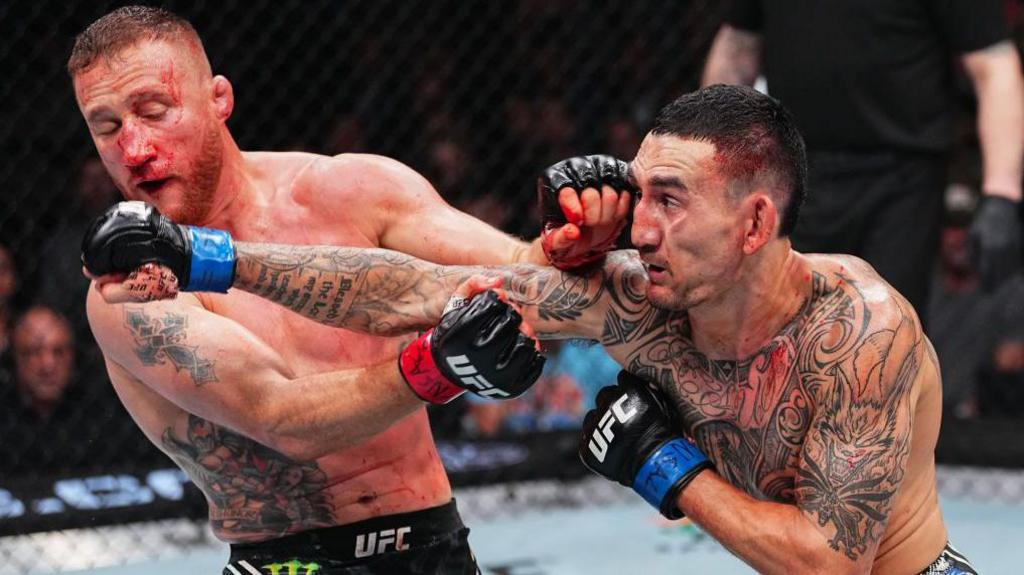

In [7]:
from google.colab import files
from PIL import Image
import io

uploaded_image = files.upload()

for filename in uploaded_image:
    image = Image.open(io.BytesIO(uploaded_image[filename]))
    print("Uploaded:", filename)
    print("Image size:", image.size)

    display(image)

In [8]:
image_tensor = transform(image).unsqueeze(0).to(device)

with torch.no_grad():
    output = model(image_tensor)
    probability = torch.sigmoid(output).item()

if probability >= 0.5:
    prediction = "ABNORMAL"
    confidence = probability * 100
else:
    prediction = "NORMAL"
    confidence = (1 - probability) * 100

print("Prediction:", prediction)
print(f"Confidence: {confidence:.2f}%")

Prediction: NORMAL
Confidence: 97.45%


In [9]:
!pip install -q gradio

In [11]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import gradio as gr


# =========================================================
# 1. DEVICE
# =========================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


# =========================================================
# 2. CREATE RESNET18 MODEL
# =========================================================

model = models.resnet18(weights=None)

num_features = model.fc.in_features

model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(num_features, 1)
)


# =========================================================
# 3. LOAD TRAINED MODEL
# =========================================================

model_path = "resnet18_ucf_crime_baseline.pth"

checkpoint = torch.load(
    model_path,
    map_location="cpu",
    weights_only=True
)

model.load_state_dict(checkpoint)

model = model.to(device)
model.eval()

print("✅ Trained ResNet18 loaded successfully!")


# =========================================================
# 4. IMAGE PREPROCESSING
# =========================================================

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("✅ Image preprocessing ready!")


# =========================================================
# 5. PREDICTION FUNCTION
# =========================================================

def analyze_image(input_image):

    try:

        if input_image is None:
            return "Please upload an image.", ""

        # Convert uploaded image to RGB
        input_image = input_image.convert("RGB")

        # Apply preprocessing
        image_tensor = transform(input_image)

        # Add batch dimension
        image_tensor = image_tensor.unsqueeze(0)

        # Move to GPU/CPU
        image_tensor = image_tensor.to(device)

        # Model prediction
        with torch.no_grad():

            output = model(image_tensor)

            probability = torch.sigmoid(output).item()


        # Classification
        if probability >= 0.5:

            prediction = "🚨 ABNORMAL"

            confidence = probability * 100

        else:

            prediction = "✅ NORMAL"

            confidence = (1 - probability) * 100


        return prediction, f"{confidence:.2f}%"


    except Exception as e:

        return f"Error: {str(e)}", ""


# =========================================================
# 6. GRADIO INTERFACE
# =========================================================

with gr.Blocks(
    title="UCF-Crime Abnormal Behaviour Detection"
) as demo:

    gr.Markdown(
        """
        # 🔍 UCF-Crime Abnormal Behaviour Detection

        ### Deep Learning Based Image Classification

        Upload an image and the trained **ResNet18** model
        will classify it as **Normal** or **Abnormal**.
        """
    )


    with gr.Row():

        # -------------------------
        # LEFT SIDE
        # -------------------------

        with gr.Column():

            image_input = gr.Image(
                type="pil",
                label="📤 Upload Image"
            )

            analyze_button = gr.Button(
                "🔎 Analyze Image",
                variant="primary"
            )


        # -------------------------
        # RIGHT SIDE
        # -------------------------

        with gr.Column():

            result_output = gr.Textbox(
                label="Prediction",
                interactive=False
            )

            confidence_output = gr.Textbox(
                label="Model Confidence",
                interactive=False
            )


    # Button action

    analyze_button.click(
        fn=analyze_image,
        inputs=image_input,
        outputs=[
            result_output,
            confidence_output
        ]
    )


# =========================================================
# 7. LAUNCH
# =========================================================

demo.launch(
    share=True
)

Device: cpu
✅ Trained ResNet18 loaded successfully!
✅ Image preprocessing ready!
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://08748cc8d76ad28b9a.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
